In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import os

# Disable oneDNN optimizations (optional)
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "2"


# Load & preprocess MNIST

In [2]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Normalize pixel values (0–255 → 0–1)
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 3. Convert labels to one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


# Model

In [3]:
# 4. Build the MLP model with three hidden layers
model = Sequential([
    Flatten(input_shape=(28, 28)),   # Input layer
    Dense(256, activation='relu'),   # Hidden layer 1
    Dense(128, activation='relu'),   # Hidden layer 2
    Dense(64, activation='relu'),    # Hidden layer 3
    Dense(10, activation='softmax')  # Output layer
])

# 5. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

c:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Train

In [4]:
# 6. Train the model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2
)

# 7. Evaluate the model
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy:.4f}")


Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.9088 - loss: 0.3118 - val_accuracy: 0.9593 - val_loss: 0.1406
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9659 - loss: 0.1138 - val_accuracy: 0.9672 - val_loss: 0.1097
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9767 - loss: 0.0756 - val_accuracy: 0.9691 - val_loss: 0.1061
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9841 - loss: 0.0525 - val_accuracy: 0.9717 - val_loss: 0.0981
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9876 - loss: 0.0399 - val_accuracy: 0.9710 - val_loss: 0.0974
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9908 - loss: 0.0292 - val_accuracy: 0.9726 - val_loss: 0.0962
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9919 - loss: 0.0244 - val_accuracy: 0.9755 - val_loss: 0.0940
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9934 - loss: 0.0200 - val_accuracy: 0.

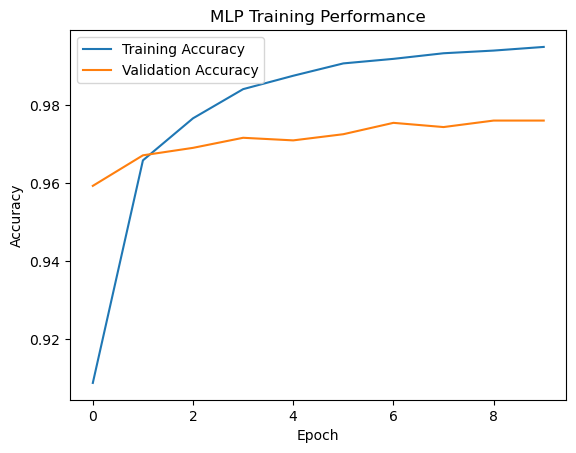

In [5]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('MLP Training Performance')
plt.show()


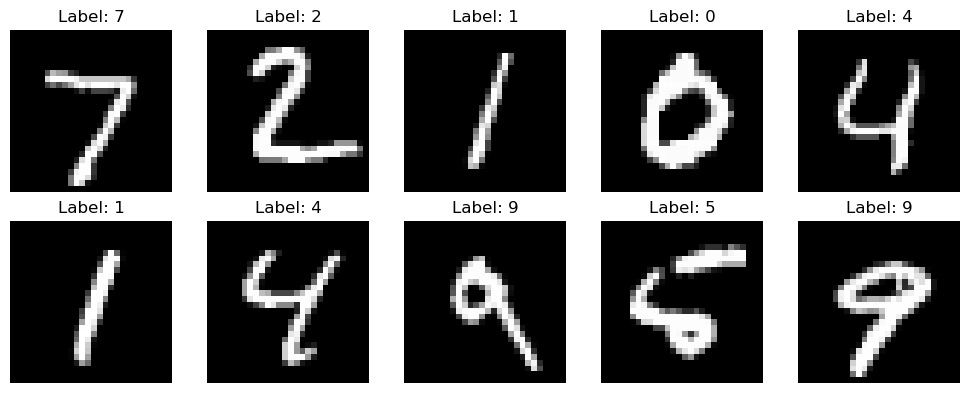

In [10]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')   # or x_train[i]
    plt.title(f"Label: {y_test[i].argmax()}")
    plt.axis('off')

plt.tight_layout()
plt.show()
